In [5]:
#Load Data

import pandas as pd

ratings = pd.read_csv(
    "../data/movie-ratings.txt",
    header=None
)


In [6]:
ratings.columns = [
    "userId",
    "movieId",
    "movieCategoryId",
    "reviewId",
    "movieRating",
    "reviewDate"
]

ratings.head()

,userId,movieId,movieCategoryId,reviewId,movieRating,reviewDate
0,1,1,1,1,5,2000-07-12
1,2,1,1,2,5,2000-07-12
2,3,1,1,3,5,2000-07-12
3,4,1,1,4,4,2000-07-12
4,5,1,1,5,4,2000-07-12


In [7]:
num_users = ratings["userId"].nunique()
num_movies = ratings["movieId"].nunique()
num_ratings = len(ratings)

print("Users:", num_users)
print("Movies:", num_movies)
print("Ratings:", num_ratings)

Users: 17615
Movies: 16121
Ratings: 72665


In [9]:
possible_ratings = num_users * num_movies
sparsity = 1 - (num_ratings / possible_ratings)

print("Sparsity:", sparsity)

Sparsity: 0.9997441115684126


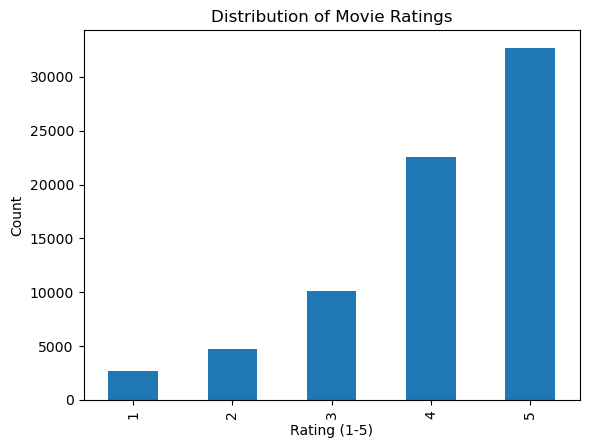

In [10]:
import matplotlib.pyplot as plt

ratings["movieRating"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating (1-5)")
plt.ylabel("Count")
plt.show()

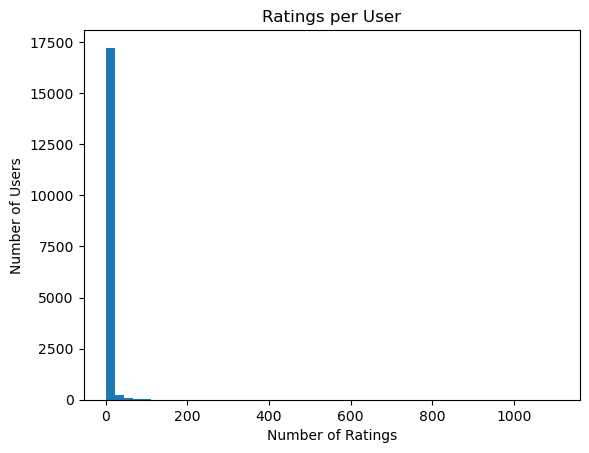

In [11]:
ratings_per_user = ratings.groupby("userId").size()

plt.hist(ratings_per_user, bins=50)
plt.title("Ratings per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")
plt.show()

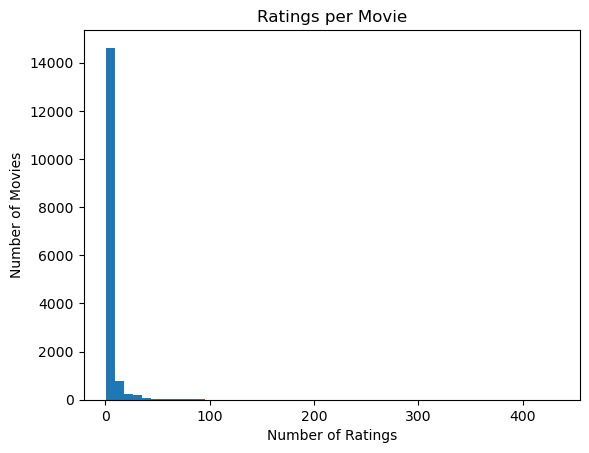

In [12]:
ratings_per_movie = ratings.groupby("movieId").size()

plt.hist(ratings_per_movie, bins=50)
plt.title("Ratings per Movie")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Movies")
plt.show()

In [13]:
print(ratings.isnull().sum())

userId             0
movieId            0
movieCategoryId    0
reviewId           0
movieRating        0
reviewDate         0
dtype: int64


In [14]:
duplicate_count = ratings.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [15]:
ratings.info()
ratings.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72665 entries, 0 to 72664
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   userId           72665 non-null  int64 
 1   movieId          72665 non-null  int64 
 2   movieCategoryId  72665 non-null  int64 
 3   reviewId         72665 non-null  int64 
 4   movieRating      72665 non-null  int64 
 5   reviewDate       72665 non-null  object
dtypes: int64(5), object(1)
memory usage: 3.3+ MB


,userId,movieId,movieCategoryId,reviewId,movieRating
count,72665.000000,72665.000000,72665.000000,72665.000000,72665.000000
mean,4279.437597,8076.878786,12.659300,36333.000000,4.072910
std,4620.200449,4397.176683,4.158915,20976.722992,1.081442
min,1.000000,1.000000,1.000000,1.000000,1.000000
25%,857.000000,4632.000000,11.000000,18167.000000,4.000000
50%,2102.000000,7623.000000,14.000000,36333.000000,4.000000
75%,6568.000000,12105.000000,16.000000,54499.000000,5.000000
max,17615.000000,16121.000000,17.000000,72665.000000,5.000000
